In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("education_inequality_data.csv")

In [3]:
df.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [4]:
df.tail()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
995,996,Hale High School,Ohio,Charter,Elementary,8775.63,51.9,18.3,12.9,61.0,50.5,10.03
996,997,Herrera Elementary School,Georgia,Public,High,24440.93,61.1,19.2,24.8,49.1,89.3,3.11
997,998,Combs High School,New York,Private,Middle,23947.18,94.2,25.2,16.7,51.1,55.8,7.14
998,999,Buckley Elementary School,Illinois,Private,Elementary,6459.87,57.0,17.0,73.6,48.4,64.0,1.21
999,1000,Berg Elementary School,Illinois,Private,Elementary,15471.48,51.6,10.9,31.1,83.9,94.2,1.53


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   school_name              1000 non-null   object 
 2   state                    1000 non-null   object 
 3   school_type              1000 non-null   object 
 4   grade_level              1000 non-null   object 
 5   funding_per_student_usd  1000 non-null   float64
 6   avg_test_score_percent   1000 non-null   float64
 7   student_teacher_ratio    1000 non-null   float64
 8   percent_low_income       1000 non-null   float64
 9   percent_minority         1000 non-null   float64
 10  internet_access_percent  1000 non-null   float64
 11  dropout_rate_percent     1000 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 93.9+ KB


In [6]:
df.columns

Index(['id', 'school_name', 'state', 'school_type', 'grade_level',
       'funding_per_student_usd', 'avg_test_score_percent',
       'student_teacher_ratio', 'percent_low_income', 'percent_minority',
       'internet_access_percent', 'dropout_rate_percent'],
      dtype='object')

In [7]:
df.isnull().sum()

id                         0
school_name                0
state                      0
school_type                0
grade_level                0
funding_per_student_usd    0
avg_test_score_percent     0
student_teacher_ratio      0
percent_low_income         0
percent_minority           0
internet_access_percent    0
dropout_rate_percent       0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
state_performance = df.groupby("state")["avg_test_score_percent"].mean().sort_values(ascending=False)

print(state_performance)

state
California        73.932990
New York          72.244211
Florida           71.600909
Texas             70.281513
Georgia           69.735514
Illinois          69.555882
Pennsylvania      69.011905
North Carolina    69.004167
Michigan          68.587640
Ohio              65.788119
Name: avg_test_score_percent, dtype: float64


In [10]:
national_avg = df["avg_test_score_percent"].mean()
print("National Average Test Score:", national_avg)

National Average Test Score: 70.00100000000006


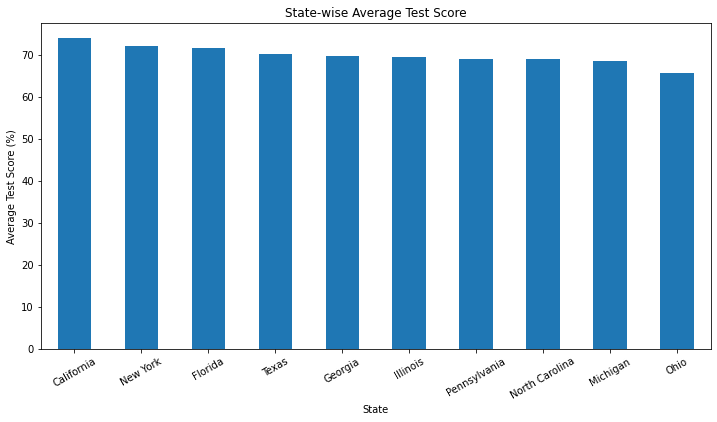

In [13]:
state_performance.plot(kind='bar', figsize=(12,6))
plt.title("State-wise Average Test Score")
plt.ylabel("Average Test Score (%)")
plt.xlabel("State")
plt.xticks(rotation=30)
plt.show()

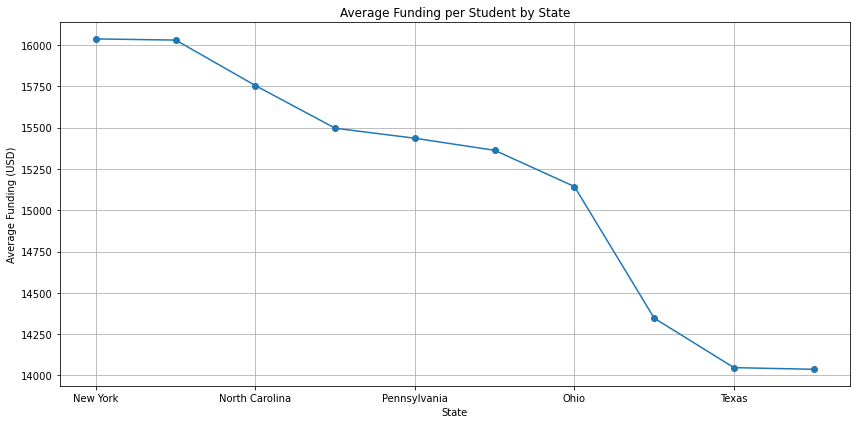

In [16]:
state_funding = df.groupby("state")["funding_per_student_usd"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_funding.plot(kind='line', marker='o')
plt.title("Average Funding per Student by State")
plt.xlabel("State")
plt.ylabel("Average Funding (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

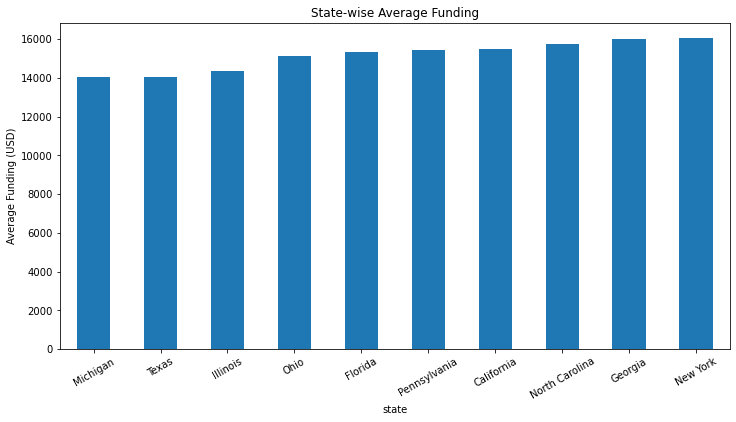

In [20]:
state_funding = df.groupby("state")["funding_per_student_usd"].mean().sort_values()

plt.figure(figsize=(12,6))
state_funding.plot(kind='bar')
plt.title("State-wise Average Funding")
plt.ylabel("Average Funding (USD)")
plt.xticks(rotation=30)
plt.show()

Comparison by School Type:
             avg_test_score_percent  funding_per_student_usd  \
school_type                                                    
Charter                   69.069632             15045.673589   
Private                   70.505634             14911.217352   
Public                    70.391223             15535.386928   

             dropout_rate_percent  
school_type                        
Charter                  8.094693  
Private                  7.760479  
Public                   7.434984  


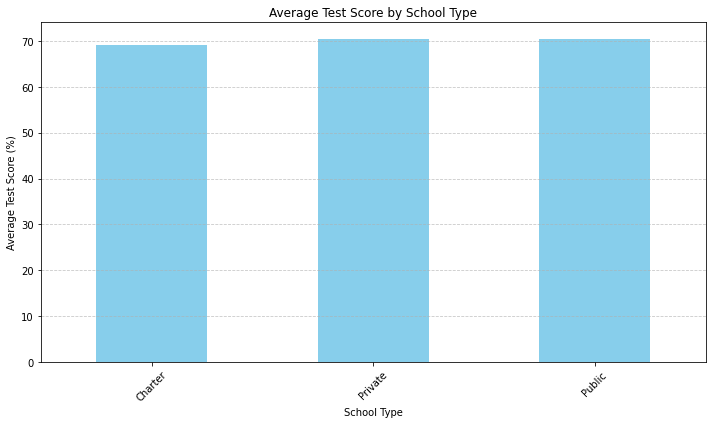

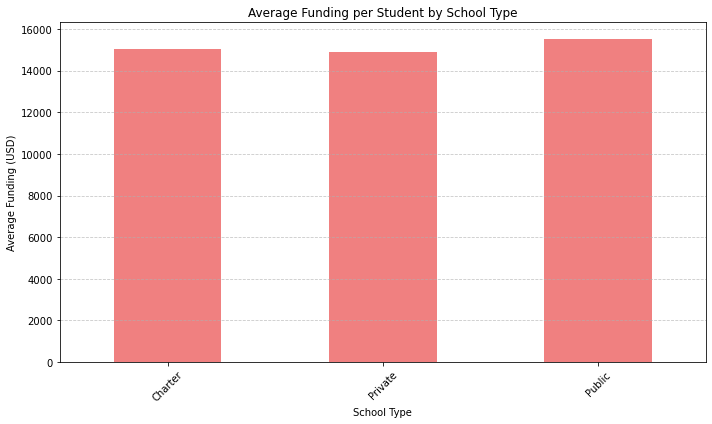

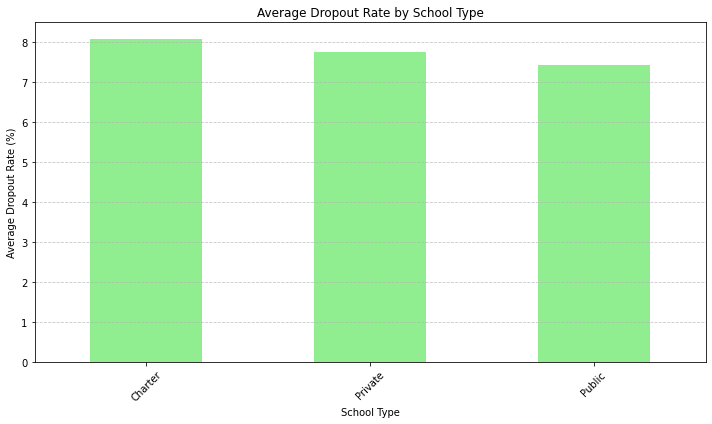

In [21]:
school_type_comparison = df.groupby("school_type")[["avg_test_score_percent", "funding_per_student_usd", "dropout_rate_percent"]].mean()

print("Comparison by School Type:")
print(school_type_comparison)

# Plotting Average Test Score by School Type
plt.figure(figsize=(10, 6))
school_type_comparison["avg_test_score_percent"].plot(kind='bar', color='skyblue')
plt.title("Average Test Score by School Type")
plt.xlabel("School Type")
plt.ylabel("Average Test Score (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Average Funding per Student by School Type
plt.figure(figsize=(10, 6))
school_type_comparison["funding_per_student_usd"].plot(kind='bar', color='lightcoral')
plt.title("Average Funding per Student by School Type")
plt.xlabel("School Type")
plt.ylabel("Average Funding (USD)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Average Dropout Rate by School Type
plt.figure(figsize=(10, 6))
school_type_comparison["dropout_rate_percent"].plot(kind='bar', color='lightgreen')
plt.title("Average Dropout Rate by School Type")
plt.xlabel("School Type")
plt.ylabel("Average Dropout Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()